Missing Values:
 crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

Summary Statistics:
              crim          zn       indus        chas         nox          rm  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.069170    0.554695    6.284634   
std      8.601545   23.322453    6.860353    0.253994    0.115878    0.702617   
min      0.006320    0.000000    0.460000    0.000000    0.385000    3.561000   
25%      0.082045    0.000000    5.190000    0.000000    0.449000    5.885500   
50%      0.256510    0.000000    9.690000    0.000000    0.538000    6.208500   
75%      3.677083   12.500000   18.100000    0.000000    0.624000    6.623500   
max     88.976200  100.000000   27.740000    1.000000    0.871000    8.780000   

              age         dis       

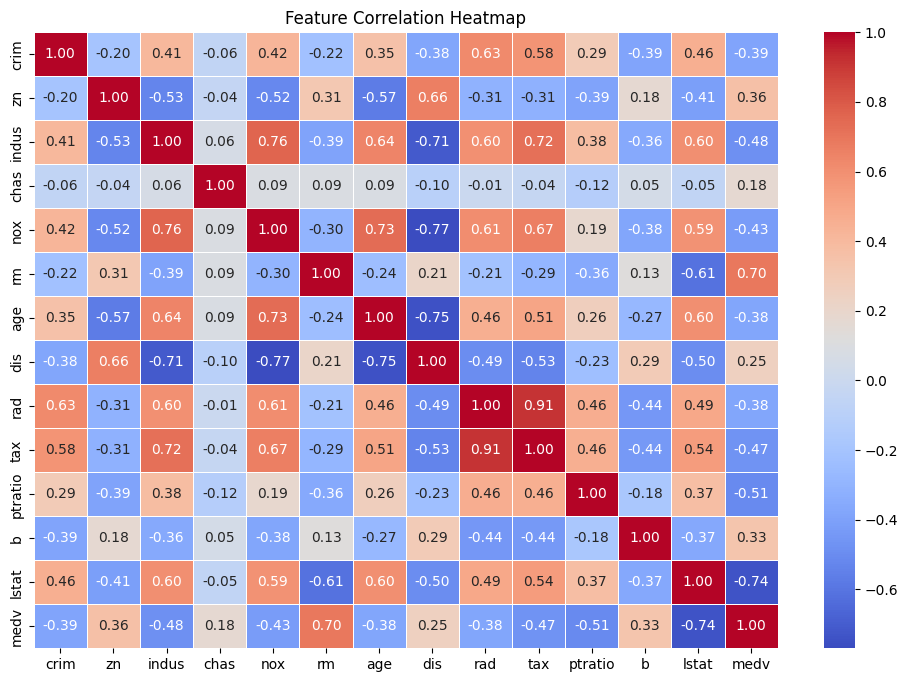

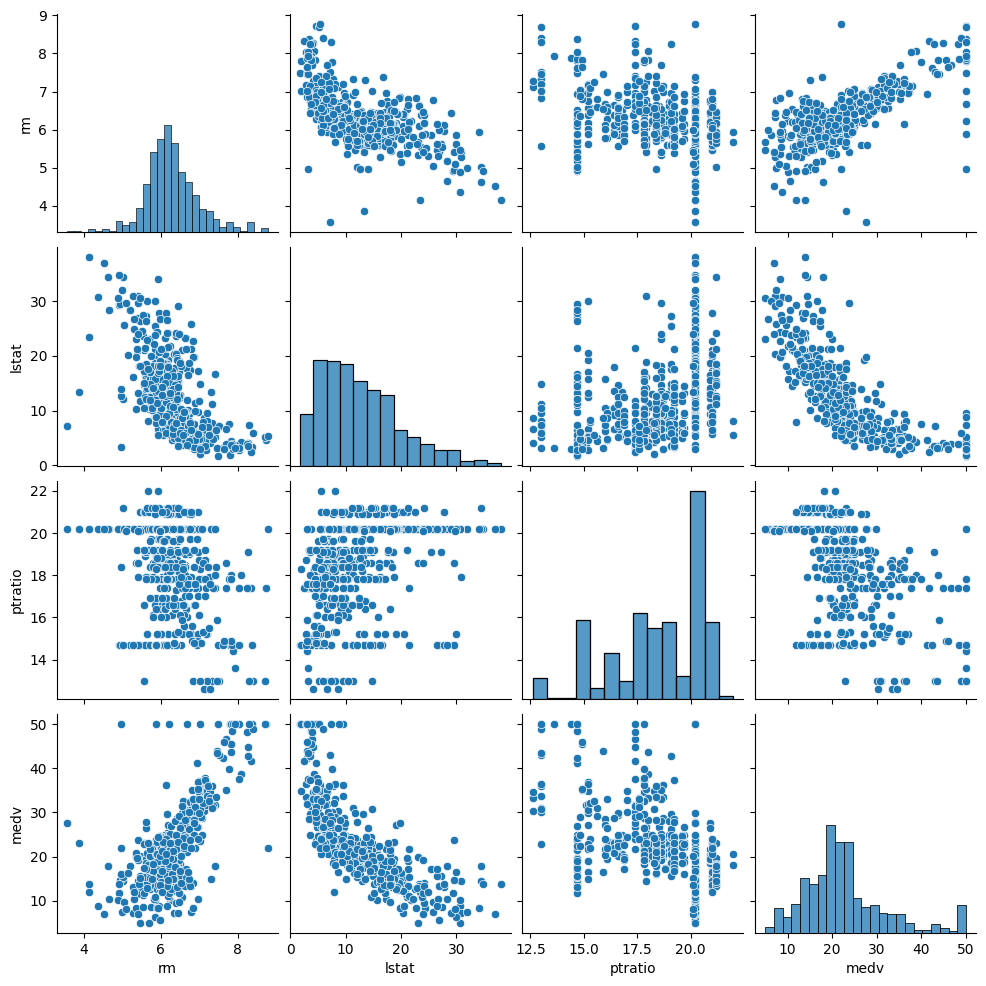

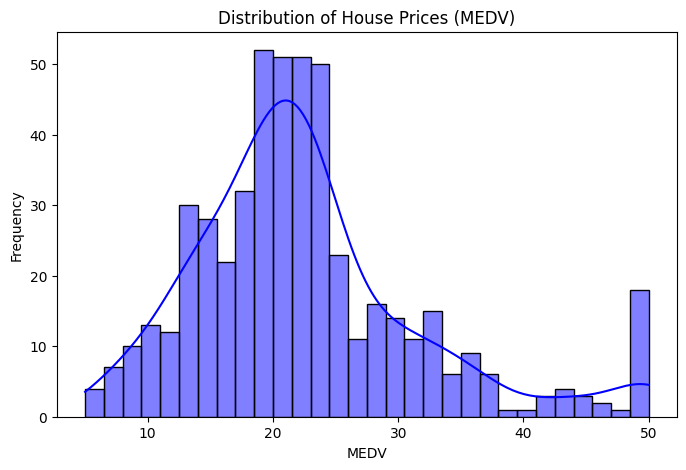

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("/content/boston.csv")

# Check for missing values
print("Missing Values:\n", df.isnull().sum())

# Summary statistics
print("\nSummary Statistics:\n", df.describe())

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
# the annotation would show the correlation values for each pair of variables in your DataFrame.
#annot=True, you're asking the heatmap to display the actual numeric value inside each colored cell.
plt.title("Feature Correlation Heatmap")

plt.show()

# Pairplot for key variables
sns.pairplot(df[['rm', 'lstat', 'ptratio', 'medv']])
plt.show()

# Distribution of target variable (MEDV)
plt.figure(figsize=(8, 5))
sns.histplot(df['medv'], bins=30, kde=True, color='blue')
plt.title("Distribution of House Prices (MEDV)")
plt.xlabel("MEDV")
plt.ylabel("Frequency")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define features (X) and target (y)
X = df.drop(columns=["medv"])  # All columns except target
y = df["medv"]

# Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
r2 = r2_score(y_test, y_pred)
#rmse = mean_squared_error(y_test, y_pred, squared=False)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.6688
RMSE: 4.9286


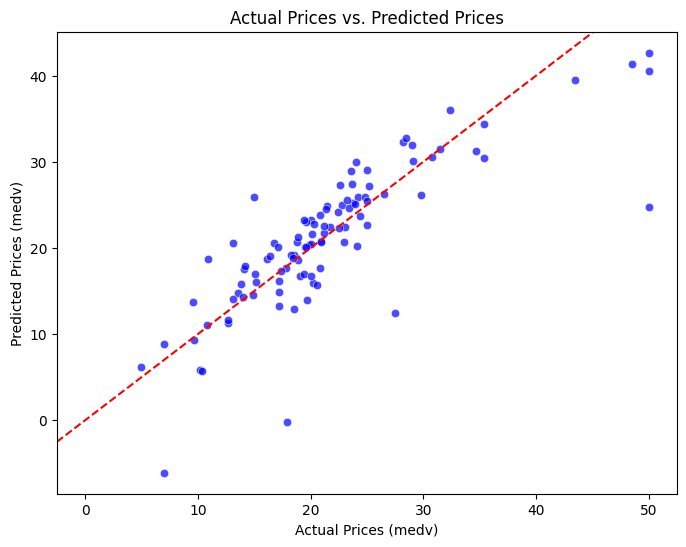

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, color='blue', alpha=0.7)
plt.xlabel("Actual Prices (medv)")
plt.ylabel("Predicted Prices (medv)")
plt.title("Actual Prices vs. Predicted Prices")
plt.axline([0,0],[1,1],color="red",linestyle="--")
plt.show()

In [ ]:
from scipy.stats import skew

In [ ]:
skewness=df.skew()

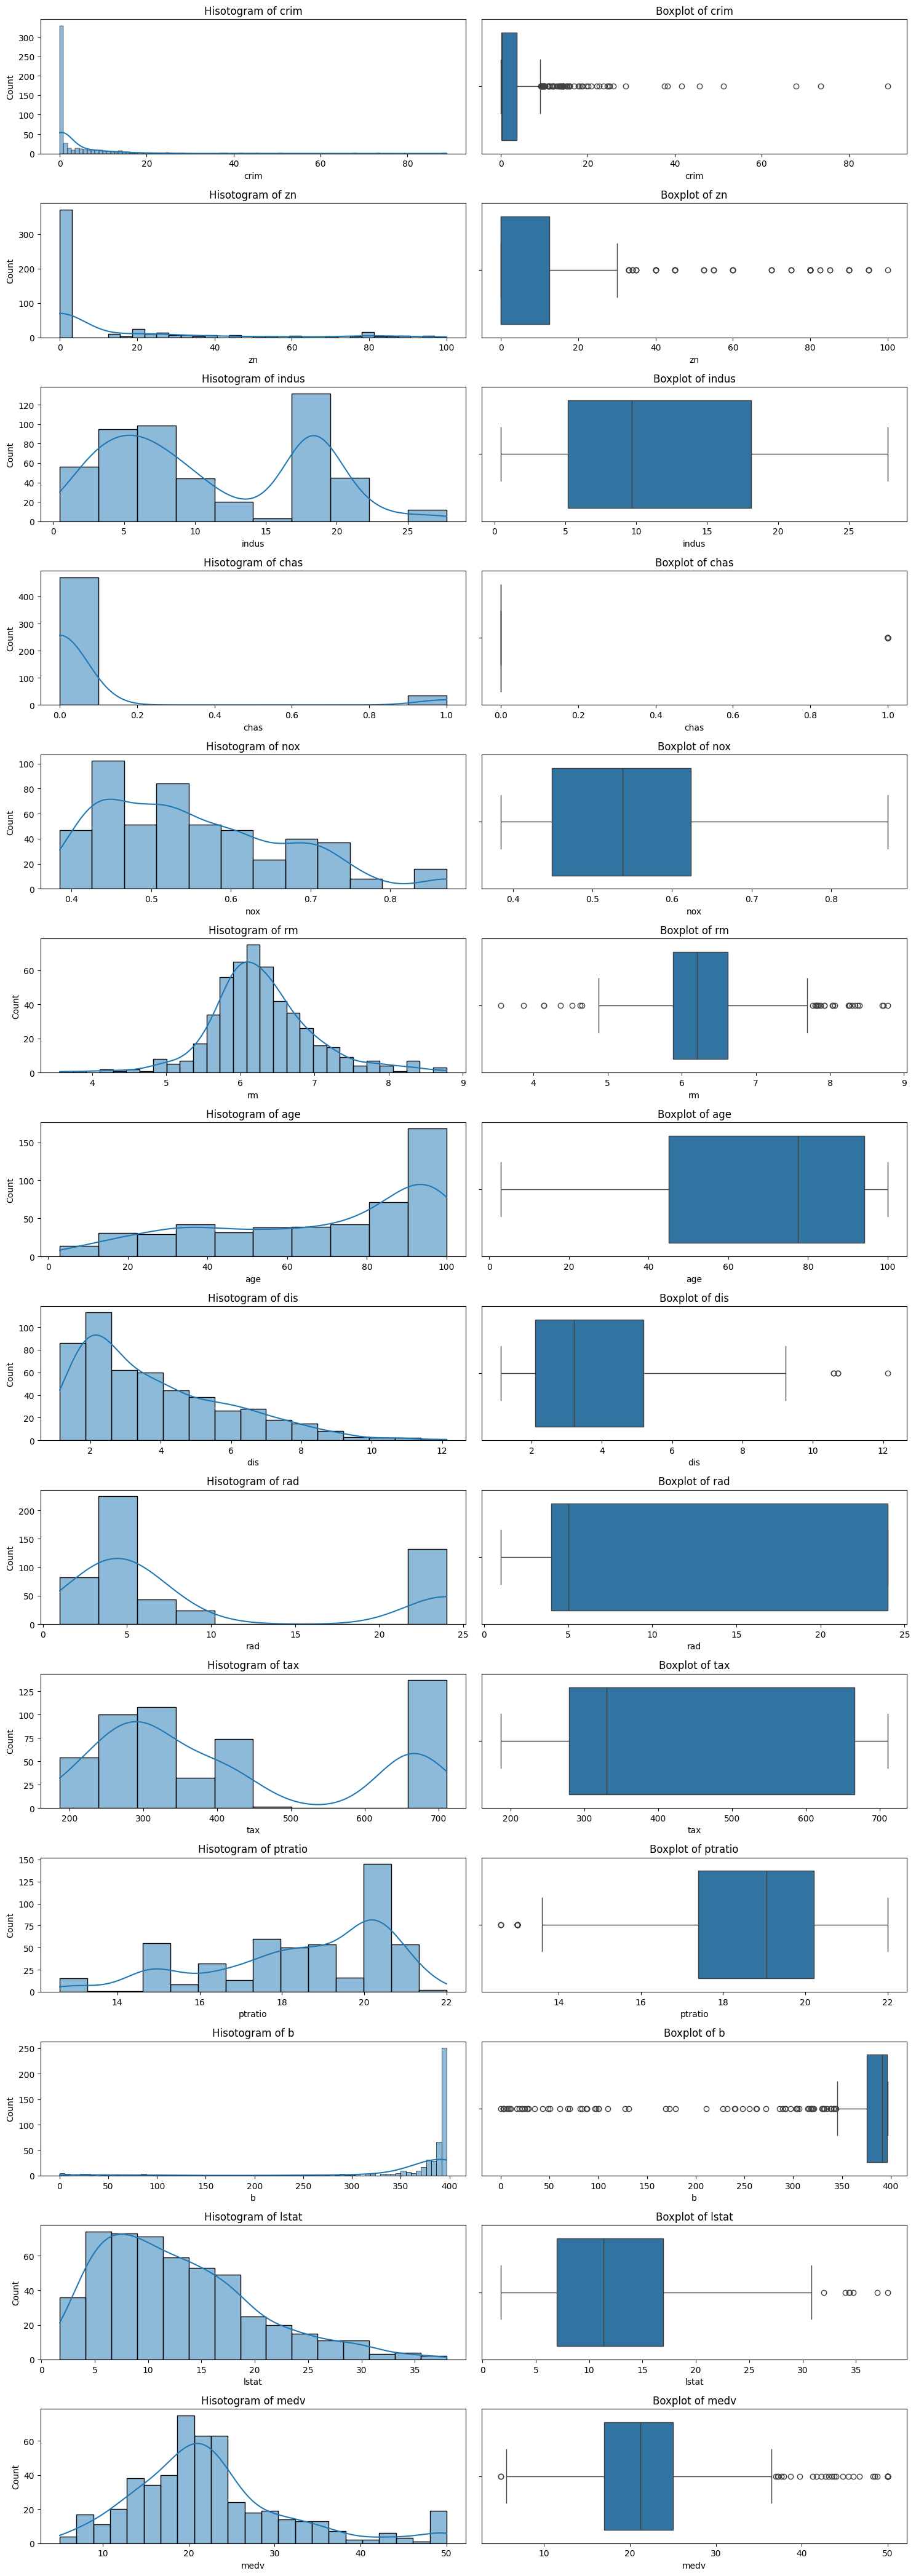

In [ ]:
#Plot histograms and boxplots

num_cols=len(df.columns)
plt.figure(figsize=(15,num_cols*3))

for i,col in enumerate(df.columns):
  plt.subplot(num_cols,2,2*i+1)
  sns.histplot(df[col],kde=True)
  plt.title(f"Hisotogram of {col}")

  plt.subplot(num_cols,2,2*i+2)
  sns.boxplot(x=df[col])
  plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

In [ ]:
skewness=df.skew()
print(skewness)

crim       5.223149
zn         2.225666
indus      0.295022
chas       3.405904
nox        0.729308
rm         0.403612
age       -0.598963
dis        1.011781
rad        1.004815
tax        0.669956
ptratio   -0.802325
b         -2.890374
lstat      0.906460
medv       1.108098
dtype: float64


In [ ]:
import numpy as np

skewed_cols=df.skew().abs()
highly_skewed=skewed_cols[skewed_cols>1].index
negatively_skewed=skewed_cols[skewed_cols< 1].index

print("Highly Skewed Columns:",highly_skewed)
print("Negatively Skewed Columns:",negatively_skewed)


Highly Skewed Columns: Index(['crim', 'zn', 'chas', 'dis', 'rad', 'b', 'medv'], dtype='object')
Negatively Skewed Columns: Index(['indus', 'nox', 'rm', 'age', 'tax', 'ptratio', 'lstat'], dtype='object')


In [ ]:
df[highly_skewed]=df[highly_skewed].apply(lambda x:np.log1p(x))

In [ ]:
from sklearn.preprocessing import PowerTransformer

pt=PowerTransformer(method='yeo-johnson')
df[negatively_skewed]=pt.fit_transform(df[negatively_skewed])


In [ ]:
df.skew()

,0
crim,1.269201
zn,1.193451
indus,-0.104641
chas,3.405904
nox,0.098431
rm,0.023275
age,-0.417736
dis,0.331561
rad,0.532760
tax,0.079613


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define features (X) and target (y)
X = df.drop(columns=["medv"])  # All columns except target
y = df["medv"]

# Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
r2 = r2_score(y_test, y_pred)
#rmse = mean_squared_error(y_test, y_pred, squared=False)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.7555
RMSE: 0.1842


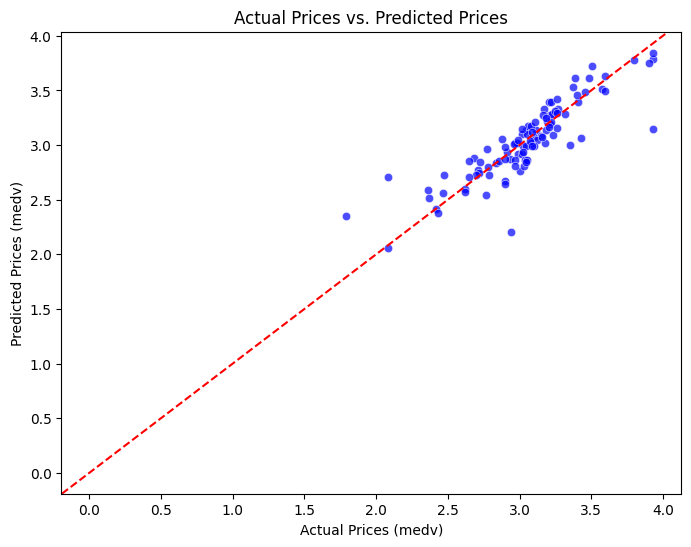

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, color='blue', alpha=0.7)
plt.xlabel("Actual Prices (medv)")
plt.ylabel("Predicted Prices (medv)")
plt.title("Actual Prices vs. Predicted Prices")
plt.axline([0,0],[1,1],color="red",linestyle="--")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model=RandomForestRegressor(n_estimators=100,random_state=42)
rf_model.fit(X_train,y_train)

y_pred=rf_model.predict(X_test)

r2=r2_score(y_test,y_pred)
rmse=mean_squared_error(y_test,y_pred)**0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.8409
RMSE: 0.1485
